<a href="https://colab.research.google.com/github/Annsjana123/Ecommerce-Sales-Analysis/blob/main/Ecommerce_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DATA CLEANING**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

In [4]:
import pandas as pd

base_path = '/content/drive/MyDrive/Olist_Data/'

customers = pd.read_csv(base_path + 'olist_customers_dataset.csv')
orders = pd.read_csv(base_path + 'olist_orders_dataset.csv')
order_items = pd.read_csv(base_path + 'olist_order_items_dataset.csv')
reviews = pd.read_csv(base_path + 'olist_order_reviews_dataset.csv')
products = pd.read_csv(base_path + 'olist_products_dataset.csv')

In [5]:
customers.info()
orders.info()
order_items.info()
reviews.info()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4

In [6]:
customers.head()
orders.head()
order_items.head()
reviews.head()
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [7]:
customers.isnull().sum()
orders.isnull().sum()
order_items.isnull().sum()
reviews.isnull().sum()
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [8]:
products['product_category_name'] = products['product_category_name'].fillna('Unknown')

In [9]:
customers.duplicated().sum()
orders.duplicated().sum()
order_items.duplicated().sum()
reviews.duplicated().sum()
products.duplicated().sum()

np.int64(0)

In [10]:
reviews = reviews.drop_duplicates()

In [11]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [12]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  object        
 7   order_estimated_delivery_date  99441 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 6.1+ MB


In [13]:
sales = pd.merge(
    orders,
    order_items,
    on='order_id',
    how='inner'
)

In [14]:
sales = pd.merge(
    sales,
    products,
    on='product_id',
    how='left'
)

In [15]:
sales = pd.merge(
    sales,
    reviews[['order_id','review_score']],
    on='order_id',
    how='left'
)

In [16]:
sales = pd.merge(
    sales,
    customers[['customer_id','customer_state']],
    on='customer_id',
    how='left'
)

In [17]:
sales['revenue'] = sales['price']

# **SALES ANALYSIS & VISUALISATIONS**

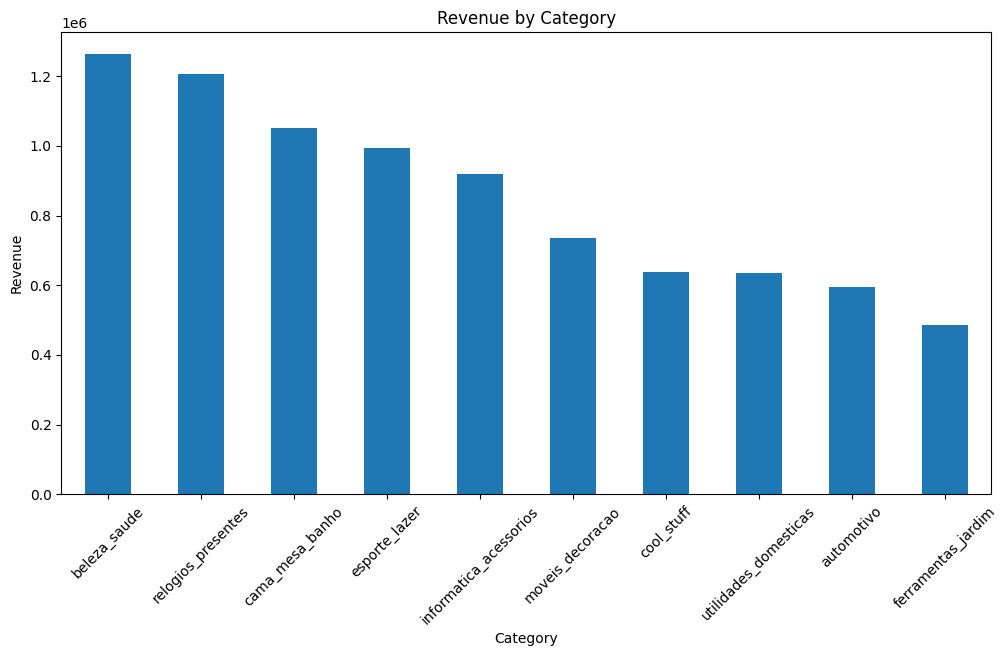

In [18]:
#Revenue by Category (Bar Chart)
category_revenue = sales.groupby('product_category_name')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
category_revenue.head(10).plot(kind='bar')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

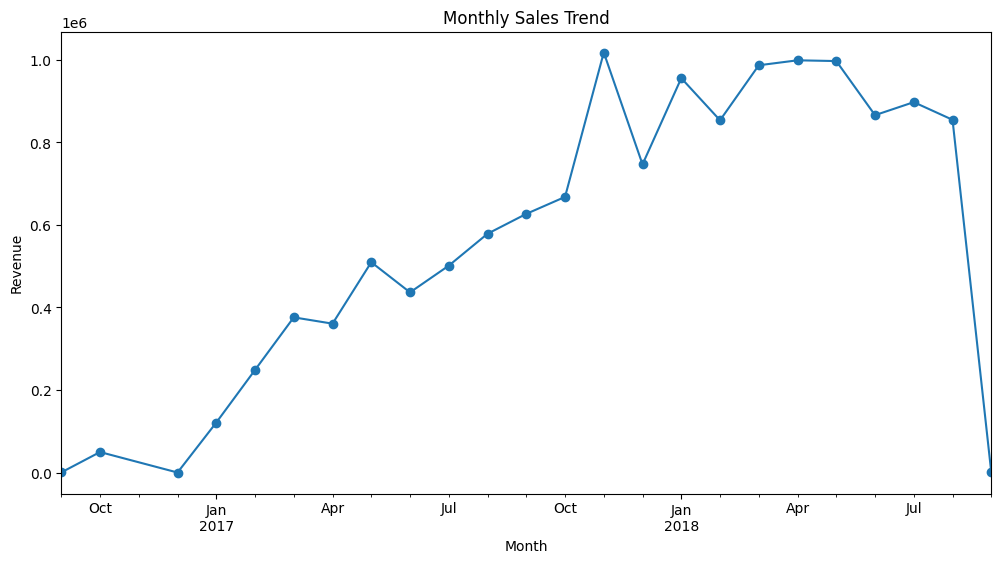

In [19]:
#Monthly Sales Trend (Line Chart)
sales['order_purchase_timestamp'] = pd.to_datetime(sales['order_purchase_timestamp'])
sales['month'] = sales['order_purchase_timestamp'].dt.to_period('M')
sales[['order_purchase_timestamp', 'month']].head()


monthly_sales = sales.groupby('month')['revenue'].sum()
plt.figure(figsize=(12, 6))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

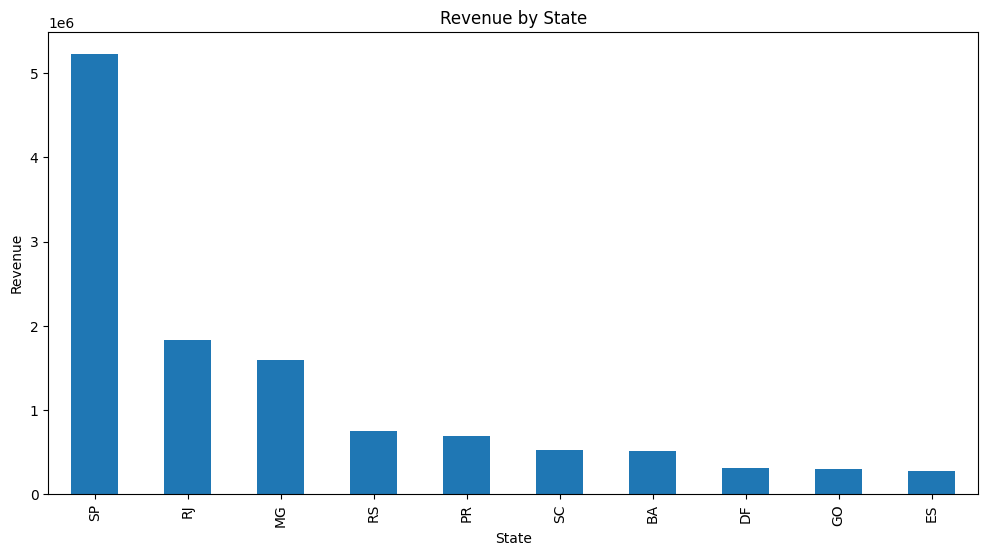

In [20]:
#Regional Sales (Bar Chart)
state_sales = sales.groupby('customer_state')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
state_sales.head(10).plot(kind='bar')
plt.title('Revenue by State')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.show()

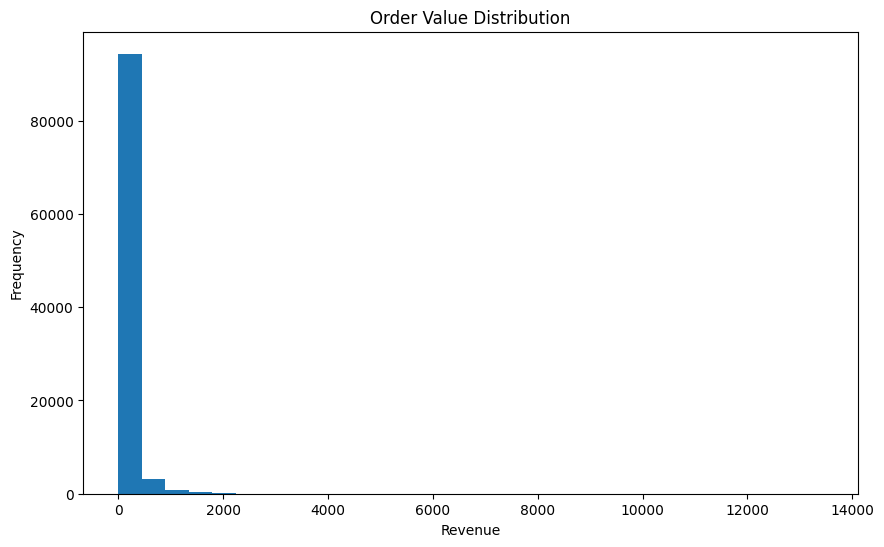

In [21]:
#Order Value Distribution (Histogram)
order_value = sales.groupby('order_id')['revenue'].sum().reset_index()
plt.figure(figsize=(10, 6))
plt.hist(order_value['revenue'], bins=30)
plt.title('Order Value Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

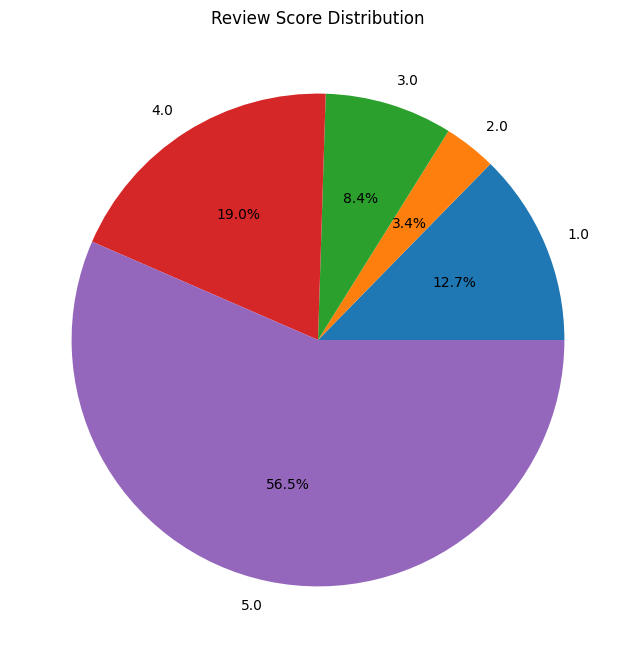

In [22]:
#Review Score Distribution (Pie Chart)
review_dist = sales['review_score'].value_counts().sort_index()
plt.figure(figsize=(8, 8))
review_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title('Review Score Distribution')
plt.ylabel('')
plt.show()

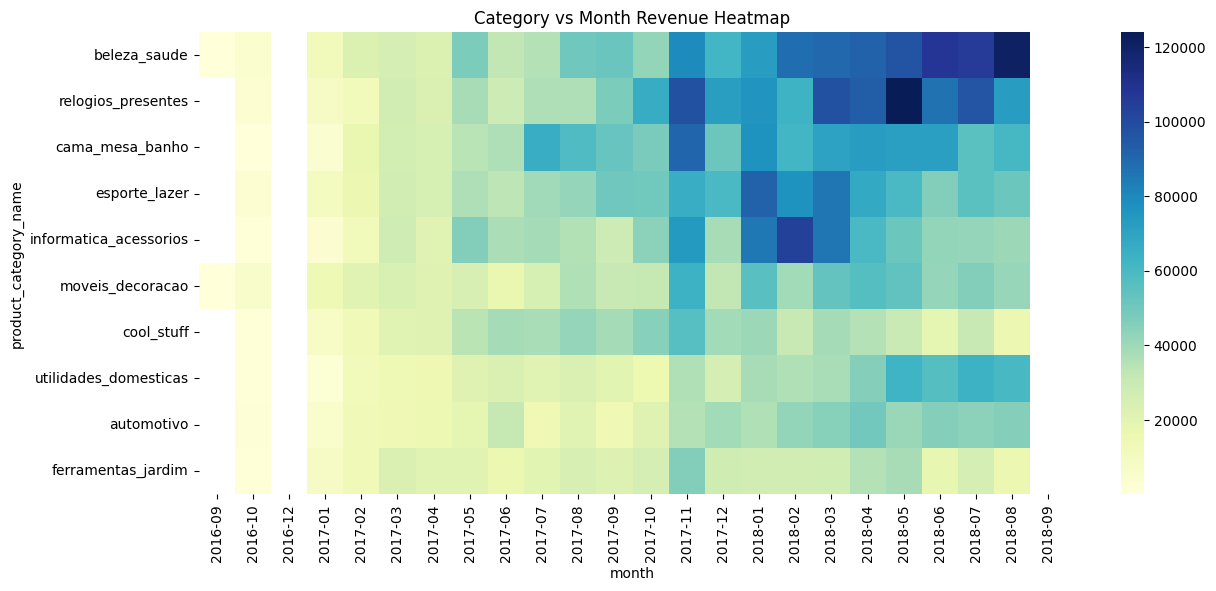

In [23]:
#Category vs. Month (Heatmap)
from pandas.core.indexes import category

heatmap_data = pd.pivot_table(sales, values='revenue', index='product_category_name', columns='month', aggfunc='sum')
top_categories = category_revenue.head(10).index
heatmap_data = heatmap_data.loc[top_categories]
plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title("Category vs Month Revenue Heatmap")
plt.show()

# **5 QUESTIONS**

In [25]:
# Highest Revenue Category
category_revenue = sales.groupby('product_category_name')['revenue'].sum().sort_values(ascending=False)

highest_category = category_revenue.idxmax()
highest_category_revenue = category_revenue.max()

# Peak Sales Month
monthly_sales = sales.groupby('month')['revenue'].sum()

peak_month = monthly_sales.idxmax()
peak_month_revenue = monthly_sales.max()

# Best Performing Region
state_sales = sales.groupby('customer_state')['revenue'].sum().sort_values(ascending=False)

best_region = state_sales.idxmax()
best_region_revenue = state_sales.max()

# Average Order Value
order_value = sales.groupby('order_id')['revenue'].sum().reset_index()

average_order_value = order_value['revenue'].mean()

# Review Score Distribution
review_distribution = sales['review_score'].value_counts().sort_index()

In [27]:
print(f"Q1 Highest Revenue Category: {highest_category}")
print(f"Q2 Peak Sales Month: {peak_month}")
print(f"Q3 Best Performing Region: {best_region}")
print(f"Q4 Average Order Value: {average_order_value:.2f}")

print("\nQ5 Review Score Distribution:")
for score, count in review_distribution.items():
    print(f"Rating {score}: {count} reviews")

Q1 Highest Revenue Category: beleza_saude
Q2 Peak Sales Month: 2017-11
Q3 Best Performing Region: SP
Q4 Average Order Value: 138.37

Q5 Review Score Distribution:
Rating 1.0: 14235 reviews
Rating 2.0: 3874 reviews
Rating 3.0: 9423 reviews
Rating 4.0: 21315 reviews
Rating 5.0: 63525 reviews


# **DASHBOARD KPI**

In [28]:
total_revenue = round(sales['revenue'].sum(), 2)
total_orders = sales['order_id'].nunique()
top_category = category_revenue.idxmax()
best_month = monthly_sales.idxmax()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Top Category:", top_category)
print("Best Month:", best_month)

Total Revenue: 13651923.47
Total Orders: 98666
Top Category: beleza_saude
Best Month: 2017-11


In [29]:
sales.to_csv('olist_cleaned_dataset.csv', index=False)

# **BUSINESS INSIGHTS AND RECOMMENDATIONS**

 1. Product categories contribute unequally to overall revenue, with a few categories accounting for most of the sales.

 * RECOMMENDATION:- Targeted marketing, inventory and promotion to the top performing categories to increase sales and profitability.


2. Monthly sales patterns show distinct seasonal fluctuations, reflecting times of peak and low customer demand.

* RECOMMENDATION:- Launch targeted promotions, discounts, and advertising campaigns during low-performing months to maintain consistent sales throughout the year.

3. Certain states generate much higher revenue than others. This shows strong regional demand and market concentration.

* RECOMMENDATION:- Improve operations and customer engagement in the areas you’re already good at, and look for opportunities to grow in the areas you’re not by localizing marketing.

4. Most of the orders are in the middle price range, indicating that customers are generally price sensitive.

* RECOMMENDATION:- Provide competitive pricing, bundle deals and value-based promotions to attract and retain customers while maintaining profitability.

5. Our customers have given us mainly positive reviews which indicate that, in general, our products and services are meeting expectations.

* RECOMMENDATION:- Keep up your high standards of product quality and customer service, and get your happy customers to leave reviews and ratings.

6. Revenue from high-performing product categories is consistently higher than that of other categories.

* RECOMMENDATION:- To take advantage of consumer demand, increase product visibility, advertising spending, and inventory allocation for these categories.

7. Despite having prospective client bases, certain regions perform worse in terms of sales.

* RECOMMENDATION:- To increase market penetration and sales growth, implement partnerships, targeted ads, and promotional efforts that are particular to the region.

8. Scores from customer reviews offer important information about the caliber of goods and services.

* RECOMMENDATION:- To spot problems early, raise customer happiness, and avoid possible income loss, keep a close eye on review patterns and client feedback.

**CONCLUSION:-** Through this analysis, we can see that growth in revenues is due to the combination of well-performing product categories, seasonality, and regional factors. Focusing on well-performing categories, implementing regional strategies, ensuring customers' satisfaction, and utilizing customer feedback would help companies improve their sales performance and foster growth.

# **SURPRISE FINDING**

* Another unexpected discovery was that there was no direct relation between the level of revenue and order volume. Some product types were providing large revenues for the firm with fewer orders because of the value of orders being higher.

* It was also noticeable that some areas with a smaller number of customers provided an above-average amount of revenue for the company, meaning the customers in these areas could be more affluent.

* Moreover, all categories had good review scores regardless of fluctuations in sales volume.